In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('supply_chain_data.csv')

In [3]:
df['Delivery_Time'] = df['Order_Processing_Time'] + df['Shipping_Time_Days']
df['Stock_Gap'] = df['Current_Stock'] - df['Demand_Forecast']
df['Total_Cost'] = df['Storage_Cost'] + df['Transportation_Cost']

In [4]:
# Feature Engineering

# 1. Slow Warehouses
location_avg_delay = df.groupby('Location')['Delivery_Time'].transform('mean')

df['Delay_Status'] = np.where(df['Delivery_Time'] > location_avg_delay, 'Slow', 'Efficient')


# 2. Inventory Imbalance Problems
# We check for warehouse having stock shortage of more than 20% or warehouse having excess stock more than 20% of required or demand forecast
def identify_stock_issue(gap):
    if gap < -0.2 * df['Demand_Forecast'].mean(): 
        return 'Shortage Stock'
    elif gap > 0.2 * df['Demand_Forecast'].mean():
        return 'Excess Stock'
    else:
        return 'Balanced'

df['Stock_Status'] = df['Stock_Gap'].apply(identify_stock_issue)


# 3. Cost Inefficiency Identification
# Top 10% highest cost warehouses -- Less Efficient
cost_threshold = df['Total_Cost'].quantile(0.90)
df['Cost_Status'] = np.where(df['Total_Cost'] > cost_threshold, 'High Cost', 'Normal Cost')

# Actionable Insights
problematic_warehouses = df[(df['Delay_Status'] == 'Slow') | 
                            (df['Stock_Status'] != 'Balanced') | 
                            (df['Cost_Status'] == 'High Cost')]

print(f"Total Warehouses analyzed: {len(df)}")
print(f"Warehouses needing attention: {len(problematic_warehouses)}\n")

print(problematic_warehouses[['Warehouse_ID', 'Location', 'Delay_Status', 'Stock_Status', 'Cost_Status']].head(10))

Total Warehouses analyzed: 500
Warehouses needing attention: 440

   Warehouse_ID       Location Delay_Status    Stock_Status  Cost_Status
0         WH239         Dallas         Slow    Excess Stock  Normal Cost
1         WH244        Houston         Slow  Shortage Stock  Normal Cost
3         WH428        Atlanta         Slow    Excess Stock    High Cost
4         WH202         Dallas         Slow  Shortage Stock  Normal Cost
5         WH211  San Francisco    Efficient    Excess Stock  Normal Cost
6         WH008        Atlanta         Slow        Balanced  Normal Cost
7         WH438        Atlanta         Slow    Excess Stock    High Cost
8         WH106       New York         Slow  Shortage Stock  Normal Cost
9         WH099       New York         Slow        Balanced  Normal Cost
10        WH366    Los Angeles    Efficient        Balanced    High Cost


In [5]:
# Solving Identified Problems

    # Inventory Balancing (Obj 2 & 3)
# Target: Ideal Stock = Demand_Forecast + 20% Safety Buffer
df['Ideal_Stock'] = (df['Demand_Forecast'] * 1.2).round(0)
df['Units_to_Shift'] = df['Ideal_Stock'] - df['Current_Stock']

    # Employee Optimization & Shifting
# Based on Monthly Sales
avg_sales_per_emp = df['Monthly_Sales'].sum() / df['Employee_Count'].sum()      # benchmark for employee count
df['Required_by_Sales'] = df['Monthly_Sales'] / avg_sales_per_emp

# Based on Efficiency
benchmark_proc_time = df['Order_Processing_Time'].quantile(0.25)                # top performing warehouse -- benchmark
df['Required_by_Efficiency'] = df['Employee_Count'] * (df['Order_Processing_Time'] / benchmark_proc_time)

# Combining both logic
df['Initial_Proposed_Emp'] = (df['Required_by_Sales'] + df['Required_by_Efficiency']) / 2

# Total employee count will be constant ---- as we are just shifting the emoloyee from one warehouse to other
total_current_employees = df['Employee_Count'].sum()
scaling_factor = total_current_employees / df['Initial_Proposed_Emp'].sum()
df['Proposed_Employee_Count'] = (df['Initial_Proposed_Emp'] * scaling_factor).round(0).astype(int)
df['Emp_Increase'] = df['Proposed_Employee_Count'] - df['Employee_Count']

    # Financial Optimization (Obj 4)
# Salary = Operational Cost - (Transportation + Storage)
df['Salary_Component'] = df['Operational_Cost'] - (df['Transportation_Cost'] + df['Storage_Cost'])

current_salary_total = df['Salary_Component'].sum()
current_logistics_total = (df['Transportation_Cost'] + df['Storage_Cost']).sum()
current_total_cost = current_salary_total + current_logistics_total


proposed_salary_total = current_salary_total                    # Salary constant (Shifting)
proposed_logistics_total = current_logistics_total * 0.85       # Logistics Optimized (15% Savings on Logistics due to Optimization on route)
proposed_total_cost = proposed_salary_total + proposed_logistics_total

    # Profit Margin Optimization (Obj 4)
avg_unit_price = 50 
total_revenue = df['Monthly_Sales'].sum() * avg_unit_price
current_profit_margin = ((total_revenue - current_total_cost) / total_revenue) * 100
proposed_profit_margin = ((total_revenue - proposed_total_cost) / total_revenue) * 100

# Logistics & Delivery (Obj 1)
df['Proposed_Shipping_Time'] = np.where(df['Delay_Status'] == 'Slow', df['Shipping_Time_Days'] * 0.85, df['Shipping_Time_Days'])
df['Delivery_Time'] = (benchmark_proc_time + df['Proposed_Shipping_Time']).round(0)

    # Results
action_plan = df[df['Delay_Status'] == 'Slow'][['Warehouse_ID', 'Location', 'Units_to_Shift', 'Emp_Increase', 'Delivery_Time']].head(20)

print(action_plan)


# Result Summary
print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"Profit Margin: {current_profit_margin:.2f}% -> {proposed_profit_margin:.2f}%")
print(f"\nCurrent Total Cost: ${current_total_cost:,.2f}")
print(f"Proposed Total Cost: ${proposed_total_cost:,.2f}")
print(f"Total Savings: ${current_total_cost - proposed_total_cost:,.2f}")

   Warehouse_ID       Location  Units_to_Shift  Emp_Increase  Delivery_Time
0         WH239         Dallas         -3345.0            25            4.0
1         WH244        Houston          3114.0            16            7.0
3         WH428        Atlanta         -1287.0             9            7.0
4         WH202         Dallas          4898.0             3            8.0
6         WH008        Atlanta           974.0            -5            8.0
7         WH438        Atlanta         -1885.0           -20            6.0
8         WH106       New York          2127.0           -48            7.0
9         WH099       New York           265.0             0            8.0
12        WH023  San Francisco          2639.0            19            8.0
14        WH080        Seattle          -917.0            10            5.0
15        WH191        Seattle          4793.0             5            6.0
17        WH233       New York          3669.0            15            6.0
20        WH

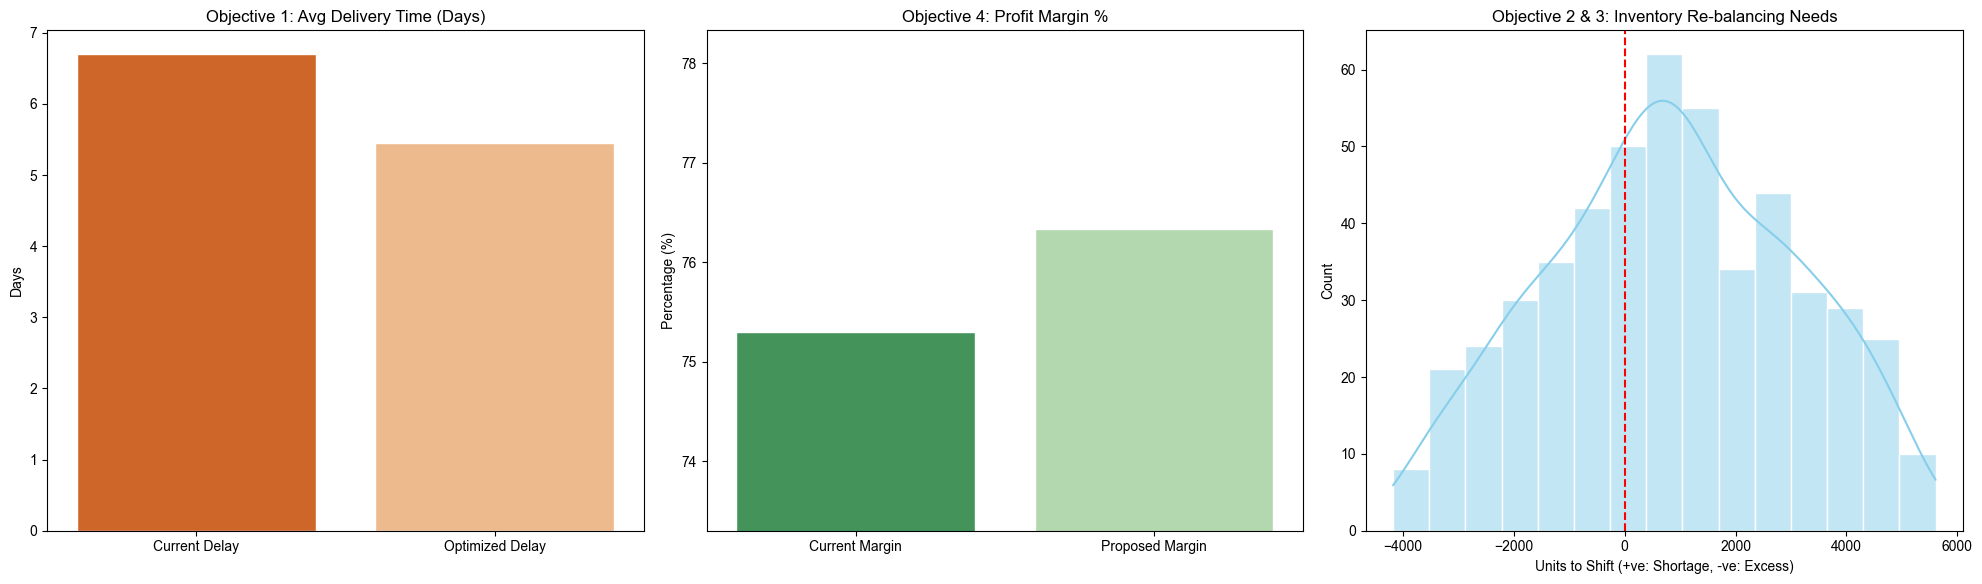

In [5]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

df['Delivery_Time_Original'] = df['Order_Processing_Time'] + df['Shipping_Time_Days']

# Figure setup
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# 1. Graph: Delivery Delay Reduction (Objective 1)
labels_delay = ['Current Delay', 'Optimized Delay']
values_delay = [df['Delivery_Time_Original'].mean(), df['Delivery_Time'].mean()]

sns.barplot(x=labels_delay, y=values_delay, ax=ax[0], hue=labels_delay, palette='Oranges_r', legend=False)
ax[0].set_title('Objective 1: Avg Delivery Time (Days)')
ax[0].set_ylabel('Days')

# 2. Graph: Profit Margin Improvement (Objective 4)
labels_margin = ['Current Margin', 'Proposed Margin']
values_margin = [current_profit_margin, proposed_profit_margin]

sns.barplot(x=labels_margin, y=values_margin, ax=ax[1], hue=labels_margin, palette='Greens_r', legend=False)

# Dynamic Y-axis to show the growth clearly
ax[1].set_ylim(min(values_margin) - 2, max(values_margin) + 2) 
ax[1].set_title('Objective 4: Profit Margin %')
ax[1].set_ylabel('Percentage (%)')

# 3. Graph: Inventory Balance (Objective 2 & 3)
sns.histplot(df['Units_to_Shift'], bins=15, ax=ax[2], color='skyblue', kde=True)
ax[2].axvline(0, color='red', linestyle='--') # Red line indicates perfect balance
ax[2].set_title('Objective 2 & 3: Inventory Re-balancing Needs')
ax[2].set_xlabel('Units to Shift (+ve: Shortage, -ve: Excess)')

plt.tight_layout()
plt.show()

In [6]:
df.to_csv('optimized_supply_chain_data.csv', index=False)